# Bank Marketing Classification – Home Task

## About Dataset – Bank Marketing Dataset

**1. Dataset Name/Title:** Bank Marketing Dataset

**2. Source:** UCI Machine Learning Repository, donated by S. Moro, P. Cortez, and P. Rita (2014). Available on Kaggle via: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

**3. Purpose:** To predict whether a client will subscribe to a term deposit (yes/no) based on bank marketing campaign data. This binary classification problem helps banks optimize their marketing strategies.

**4. Size/Dimensions:**
- Total Records: 41,188 samples
- Features: 20 attributes (mix of numeric and categorical) + 1 target variable
- Structure: 41,188 rows × 21 columns
- Class Distribution: 36,548 'no' (88.7%), 4,640 'yes' (11.3%) – imbalanced dataset

**5. Description of Features:**

| Feature | Description | Data Type |
|---------|-------------|-----------|
| age | Client's age | Numeric |
| job | Type of job (admin, technician, etc.) | Categorical |
| marital | Marital status | Categorical |
| education | Education level | Categorical |
| default | Has credit in default? | Binary (yes/no) |
| housing | Has housing loan? | Binary (yes/no) |
| loan | Has personal loan? | Binary (yes/no) |
| contact | Contact communication type | Categorical |
| month | Last contact month | Categorical |
| day_of_week | Last contact day | Categorical |
| duration | Last contact duration (seconds) | Numeric |
| campaign | Number of contacts performed | Numeric |
| pdays | Days since last contact | Numeric |
| previous | Number of previous contacts | Numeric |
| poutcome | Outcome of previous campaign | Categorical |
| emp.var.rate | Employment variation rate | Numeric |
| cons.price.idx | Consumer price index | Numeric |
| cons.conf.idx | Consumer confidence index | Numeric |
| euribor3m | Euribor 3-month rate | Numeric |
| nr.employed | Number of employees | Numeric |

**6. Target Variable:**
| Class Label | Description | Sample Count |
|-------------|-------------|--------------|
| no | Client did not subscribe | 36,548 |
| yes | Client subscribed to term deposit | 4,640 |

**Additional Notes:**
- Contains both categorical and numeric features
- Class imbalance present (11.3% positive class)
- Requires encoding for categorical variables
- 'duration' attribute is highly predictive but only known after call

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

C:\Users\shaki\PycharmProjects\JupyterProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Download Dataset from Kaggle

In [3]:
# Download latest version from Kaggle
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\shaki\.cache\kagglehub\datasets\henriqueyamahata\bank-marketing\versions\1
Path to dataset files: C:\Users\shaki\.cache\kagglehub\datasets\henriqueyamahata\bank-marketing\versions\1


In [5]:
# Load the dataset (semicolon-separated)
import os

df = pd.read_csv(os.path.join(path, 'bank-additional-full.csv'), sep=";")
print("Dataset loaded successfully!")

Dataset loaded successfully!
Dataset loaded successfully!


## Step 2: Exploratory Data Analysis (EDA)

In [7]:
# Check dataset shape
df.shape

(41188, 21)

(41188, 21)

In [9]:
# View first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [11]:
# View last 5 rows
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [13]:
# Statistical summary for numeric columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [15]:
# Check for missing/null values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [17]:
# Check target variable distribution
print("Target Variable Distribution:")
print(df['y'].value_counts())
print("\nPercentage distribution:")
print(df['y'].value_counts(normalize=True) * 100)

Target Variable Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage distribution:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64
Target Variable Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage distribution:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [19]:
# Check column data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Step 3: Data Visualization

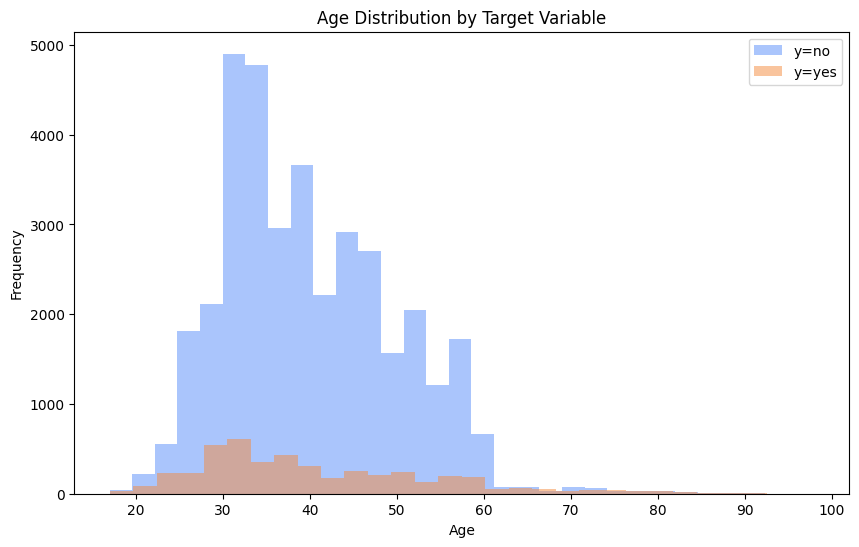

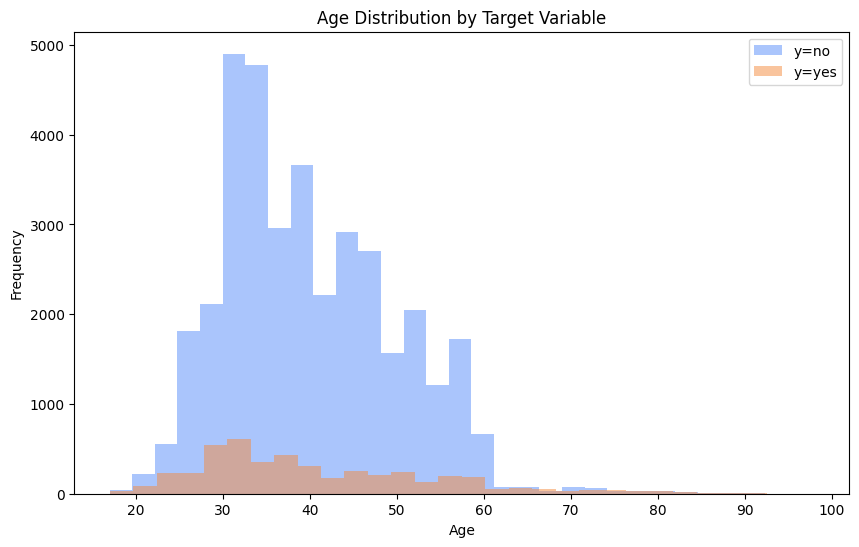

In [21]:
# Plot age distribution by target
plt.figure(figsize=(10, 6))
for label in df['y'].unique():
    subset = df[df['y'] == label]
    plt.hist(subset['age'], alpha=0.5, label=f'y={label}', bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Target Variable')
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

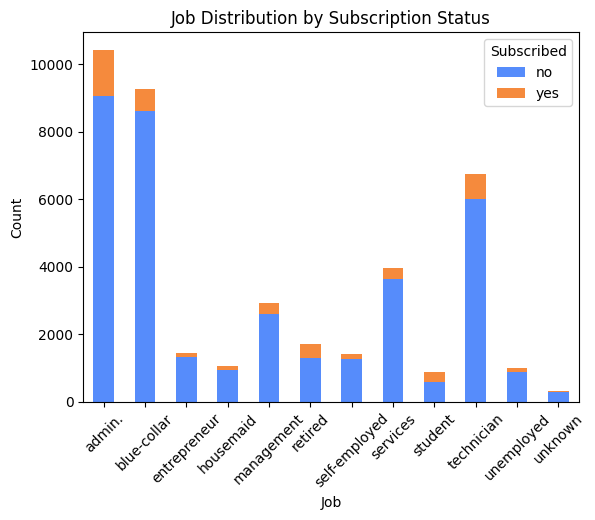

<Figure size 1200x600 with 0 Axes>

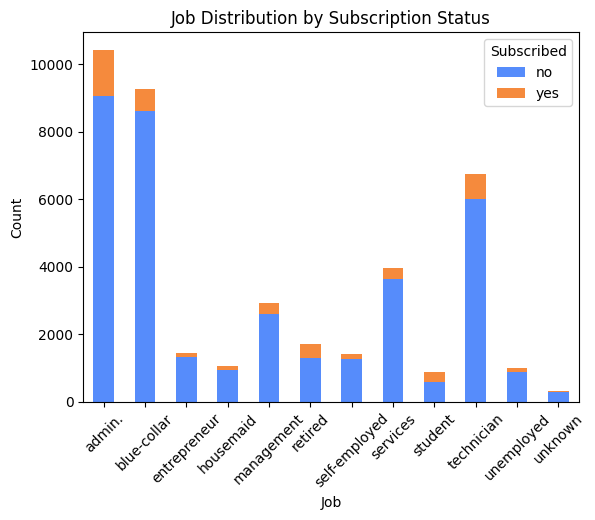

In [23]:
# Job distribution by target
plt.figure(figsize=(12, 6))
job_crosstab = pd.crosstab(df['job'], df['y'])
job_crosstab.plot(kind='bar', stacked=True)
plt.title('Job Distribution by Subscription Status')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Subscribed')
plt.show()

## Step 4: Data Preprocessing

In [25]:
# Create a copy for preprocessing
df_processed = df.copy()

# Initialize label encoders
label_encoders = {}

# Encode categorical columns
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'day_of_week', 'poutcome']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

# Encode target variable
df_processed['y'] = LabelEncoder().fit_transform(df_processed['y'])

print("Label encoding completed!")
print("\nEncoded target variable:")
print(df_processed['y'].value_counts())

Label encoding completed!

Encoded target variable:
y
0    36548
1     4640
Name: count, dtype: int64
Label encoding completed!

Encoded target variable:
y
0    36548
1     4640
Name: count, dtype: int64


In [27]:
# Split features and target
X = df_processed.drop('y', axis=1)
y = df_processed['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (41188, 20)
Target shape: (41188,)
Features shape: (41188, 20)
Target shape: (41188,)


In [29]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!
Feature scaling completed!


## Step 5: Train-Test Split

In [31]:
# Split data into training and testing sets (same as Experiment 4)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

Training set size: 32950
Test set size: 8238

Training set class distribution:
y
0    88.75569
1    11.24431
Name: proportion, dtype: float64
Training set size: 32950
Test set size: 8238

Training set class distribution:
y
0    88.75569
1    11.24431
Name: proportion, dtype: float64


## Step 6: Model Training – Logistic Regression

In [33]:
# Initialize Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)

In [35]:
# Train the model
model.fit(X_train, y_train)
print("Model training completed!")

Model training completed!
Model training completed!


## Step 7: Model Evaluation

In [37]:
# Make predictions
y_pred = model.predict(X_test)

# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [39]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Percentage: {accuracy * 100:.2f}%")

Accuracy: 0.9104
Percentage: 91.04%
Accuracy: 0.9104
Percentage: 91.04%


In [41]:
# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7303
         Yes       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7303
         Yes       0.67      0.42      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.73      8238
weighted avg       0.90      0.91      0.90      8238



In [43]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7108  195]
 [ 543  392]]
Confusion Matrix:
[[7108  195]
 [ 543  392]]


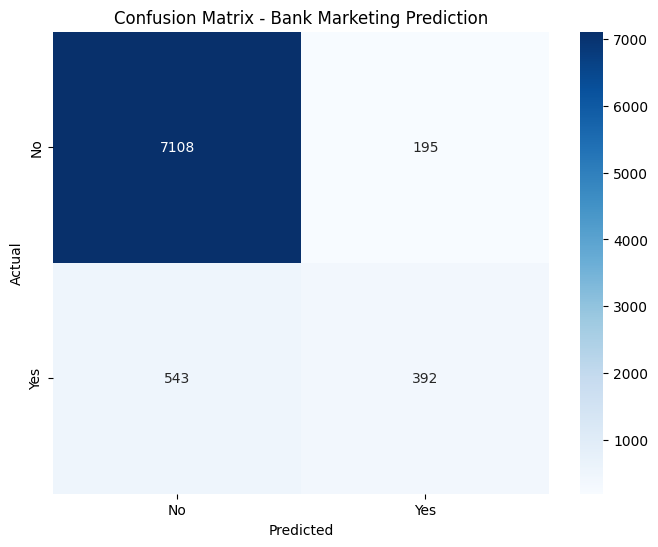

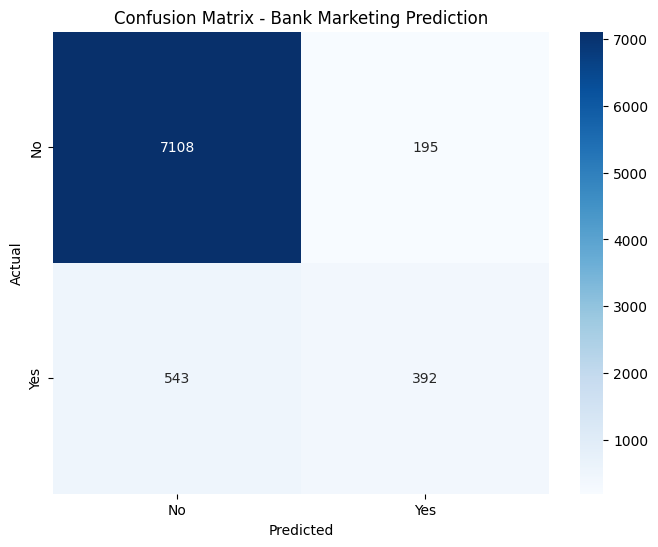

In [45]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bank Marketing Prediction')
plt.show()

## Step 8: Feature Importance

In [47]:
# Get feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
           Feature  Coefficient
15    emp.var.rate    -1.446053
10        duration     1.168767
18       euribor3m     1.087772
19     nr.employed    -0.912762
16  cons.price.idx     0.438766
7          contact    -0.363592
8            month    -0.256204
12           pdays    -0.194191
14        poutcome     0.163013
4          default    -0.147337
Top 10 Most Important Features:
           Feature  Coefficient
15    emp.var.rate    -1.446053
10        duration     1.168767
18       euribor3m     1.087772
19     nr.employed    -0.912762
16  cons.price.idx     0.438766
7          contact    -0.363592
8            month    -0.256204
12           pdays    -0.194191
14        poutcome     0.163013
4          default    -0.147337


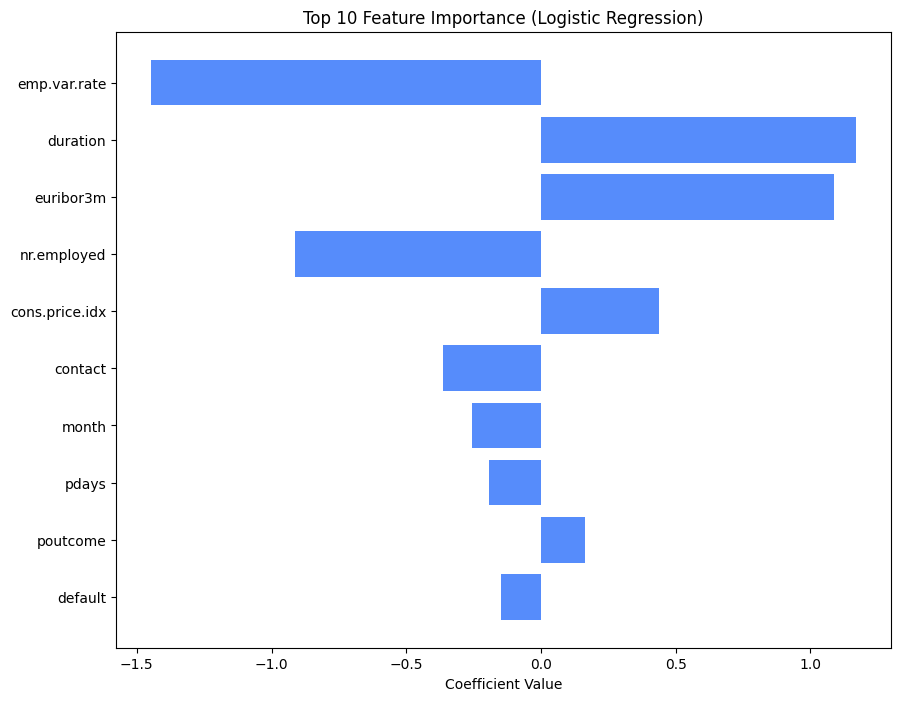

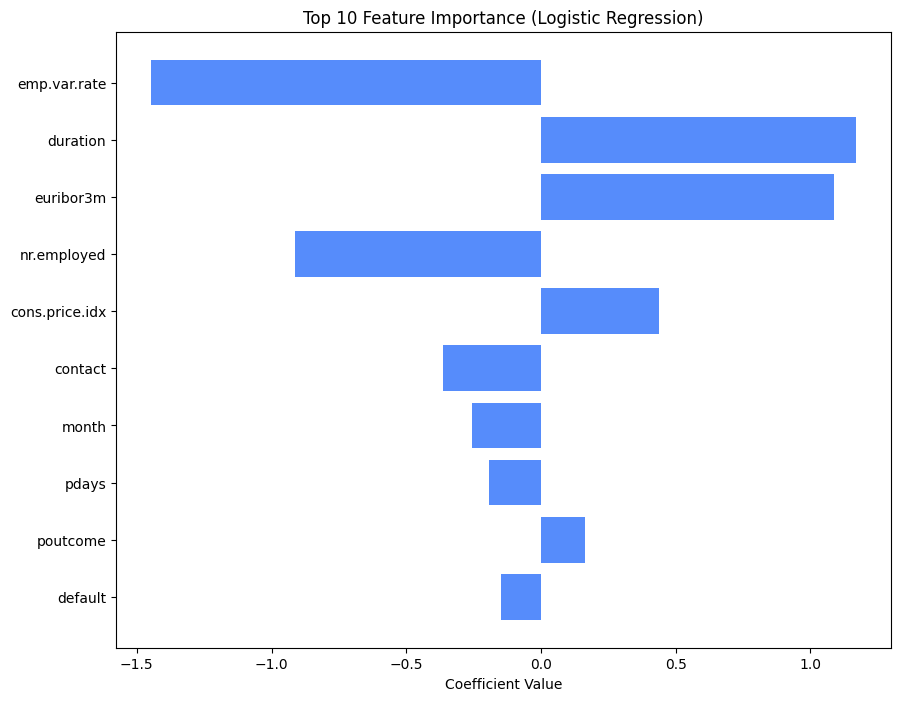

In [49]:
# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance (Logistic Regression)')
plt.gca().invert_yaxis()
plt.show()

## Step 9: Prediction Function

In [51]:
def predict_subscription(age, job, marital, education, default, housing, loan,
                         contact, month, day_of_week, duration, campaign, pdays,
                         previous, poutcome, emp_var_rate, cons_price_idx,
                         cons_conf_idx, euribor3m, nr_employed):
    """
    Predict whether a client will subscribe to a term deposit.
    
    Parameters:
    -----------
    All 20 features of the Bank Marketing dataset
    
    Returns:
    --------
    str: 'Will Subscribe' or 'Will Not Subscribe'
    """
    # Create input DataFrame
    input_data = pd.DataFrame({
        'age': [age],
        'job': [job],
        'marital': [marital],
        'education': [education],
        'default': [default],
        'housing': [housing],
        'loan': [loan],
        'contact': [contact],
        'month': [month],
        'day_of_week': [day_of_week],
        'duration': [duration],
        'campaign': [campaign],
        'pdays': [pdays],
        'previous': [previous],
        'poutcome': [poutcome],
        'emp.var.rate': [emp_var_rate],
        'cons.price.idx': [cons_price_idx],
        'cons.conf.idx': [cons_conf_idx],
        'euribor3m': [euribor3m],
        'nr.employed': [nr_employed]
    })

    # Encode categorical variables
    for col in ['job', 'marital', 'education', 'default', 'housing',
                'loan', 'contact', 'month', 'day_of_week', 'poutcome']:
        if col in label_encoders:
            input_data[col] = label_encoders[col].transform(input_data[col])

    # Scale features
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)

    return 'Will Subscribe' if prediction[0] == 1 else 'Will Not Subscribe'

### Test the Prediction Function

In [53]:
# Test with a sample from the dataset
sample = df.iloc[0]
print("Sample features:")
print(sample.to_dict())
print("\nActual result:", 'Subscribed' if sample['y'] == 'yes' else 'Not Subscribed')

# Predict
result = predict_subscription(
    age=sample['age'],
    job=sample['job'],
    marital=sample['marital'],
    education=sample['education'],
    default=sample['default'],
    housing=sample['housing'],
    loan=sample['loan'],
    contact=sample['contact'],
    month=sample['month'],
    day_of_week=sample['day_of_week'],
    duration=sample['duration'],
    campaign=sample['campaign'],
    pdays=sample['pdays'],
    previous=sample['previous'],
    poutcome=sample['poutcome'],
    emp_var_rate=sample['emp.var.rate'],
    cons_price_idx=sample['cons.price.idx'],
    cons_conf_idx=sample['cons.conf.idx'],
    euribor3m=sample['euribor3m'],
    nr_employed=sample['nr.employed']
)
print("Prediction:", result)

Sample features:
{'age': 56, 'job': 'housemaid', 'marital': 'married', 'education': 'basic.4y', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'telephone', 'month': 'may', 'day_of_week': 'mon', 'duration': 261, 'campaign': 1, 'pdays': 999, 'previous': 0, 'poutcome': 'nonexistent', 'emp.var.rate': 1.1, 'cons.price.idx': 93.994, 'cons.conf.idx': -36.4, 'euribor3m': 4.857, 'nr.employed': 5191.0, 'y': 'no'}

Actual result: Not Subscribed
Prediction: Will Not Subscribe
Sample features:
{'age': 56, 'job': 'housemaid', 'marital': 'married', 'education': 'basic.4y', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'telephone', 'month': 'may', 'day_of_week': 'mon', 'duration': 261, 'campaign': 1, 'pdays': 999, 'previous': 0, 'poutcome': 'nonexistent', 'emp.var.rate': 1.1, 'cons.price.idx': 93.994, 'cons.conf.idx': -36.4, 'euribor3m': 4.857, 'nr.employed': 5191.0, 'y': 'no'}

Actual result: Not Subscribed
Prediction: Will Not Subscribe


## Conclusion

This notebook successfully replicated all operations from Experiment 4 (Iris Classification) on the Bank Marketing dataset:

1. Dataset loading using KaggleHub
2. Comprehensive EDA (shape, head, tail, describe, isnull, info)
3. Data visualization (age distribution, job analysis)
4. Preprocessing (Label Encoding, Feature Scaling)
5. Train-Test Split (80/20 with random_state=42)
6. Logistic Regression model training
7. Evaluation (Accuracy, Classification Report, Confusion Matrix)
8. Feature importance analysis
9. Custom prediction function

**Key Differences from Experiment 4:**
- Bank Marketing has mixed data types (numeric + categorical) requiring Label Encoding
- Class imbalance present (11.3% positive class)
- Larger dataset (41,188 vs 150 samples)
- More features (20 vs 4 features)